# Spotify Decoded — Deep Listening Analysis

The EDA established the shape of the data. This notebook goes further — looking at how I actually engage with music: how long sessions last, which artists earn the most attention, how shuffle and skip behaviour interact, and what the longest streaks reveal about listening habits.


## Setup

In [1]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from spotify_parser import load_all

df_tracks, _ = load_all("../data/raw/")

# Add derived columns
df_tracks["hour"]      = df_tracks["ts_local"].dt.hour
df_tracks["dow"]       = df_tracks["ts_local"].dt.dayofweek
df_tracks["date"]      = df_tracks["ts_local"].dt.date
df_tracks["year"]      = df_tracks["ts_local"].dt.year
df_tracks["month"]     = df_tracks["ts_local"].dt.month
df_tracks["minutes"]   = df_tracks["ms_played"] / 60_000
df_tracks["completed"] = df_tracks["reason_end"] == "trackdone"
df_tracks["skipped"]   = df_tracks["skipped"].fillna(False).astype(bool)

def norm_platform(p):
    if not isinstance(p, str): return "Other"
    p = p.lower()
    if "android" in p: return "Android"
    if "windows" in p: return "Windows"
    if "osx" in p or "mac" in p: return "macOS"
    return "Other"

df_tracks["platform_clean"] = df_tracks["platform"].apply(norm_platform)

PALETTE = {
    "primary":  "#1DB954",
    "accent":   "#FF6B6B",
    "muted":    "#B3B3B3",
    "dark":     "#191414",
    "windows":  "#0078D4",
    "android":  "#3DDC84",
    "macos":    "#999999",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.family":      "sans-serif",
    "figure.dpi":       150,
})

print(f"Loaded {len(df_tracks):,} tracks")


Loaded 80,623 raw records from 9 files
  → 80,512 music tracks
  → 111 podcast plays
  → Date range: 2020-10-31 → 2026-04-02
  → Total listening: 2728.7 hours
Loaded 80,512 tracks


---
## 1. Listening sessions

A session is a continuous block of listening — I define one as ending when there's a gap of more than 30 minutes between plays. Across 5.5 years that produces 5,485 sessions.


In [2]:
# Build sessions (30-minute gap threshold)
t = df_tracks.sort_values("ts").copy()
t["gap_min"] = t["ts"].diff().dt.total_seconds() / 60
t["new_session"] = t["gap_min"].isna() | (t["gap_min"] > 30)
t["session_id"] = t["new_session"].cumsum()

sessions = t.groupby("session_id").agg(
    duration_min = ("minutes", "sum"),
    tracks       = ("track_name", "count"),
    start_hour   = ("hour", "first"),
    year         = ("year", "first"),
).reset_index()

print(f"Total sessions:          {len(sessions):,}")
print(f"Median session length:   {sessions['duration_min'].median():.0f} min  |  {sessions['tracks'].median():.0f} tracks")
print(f"Mean session length:     {sessions['duration_min'].mean():.0f} min")
print(f"Sessions over 1 hour:    {(sessions['duration_min'] > 60).sum():,}")
print(f"Sessions over 3 hours:   {(sessions['duration_min'] > 180).sum():,}")


Total sessions:          5,485
Median session length:   13 min  |  6 tracks
Mean session length:     30 min
Sessions over 1 hour:    815
Sessions over 3 hours:   81


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Session length distribution
bins = [0, 10, 30, 60, 120, 180, 300, sessions["duration_min"].max()]
labels = ["<10m", "10-30m", "30-60m", "1-2h", "2-3h", "3-5h", "5h+"]
sessions["length_bucket"] = pd.cut(sessions["duration_min"], bins=bins, labels=labels)
bucket_counts = sessions["length_bucket"].value_counts().reindex(labels)

axes[0].bar(labels, bucket_counts.values, color=PALETTE["primary"],
            alpha=0.85, edgecolor="none", width=0.7)
axes[0].set_title("Session length distribution", fontweight="bold", pad=10)
axes[0].set_ylabel("Number of sessions")
axes[0].set_xlabel("Session length")
for i, v in enumerate(bucket_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=8)

# When sessions start
session_hours = sessions["start_hour"].value_counts().sort_index()
axes[1].bar(session_hours.index, session_hours.values,
            color=PALETTE["dark"], alpha=0.8, edgecolor="none", width=0.85)
axes[1].set_title("When sessions start (hour of day)", fontweight="bold", pad=10)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Sessions")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig("../outputs/02_sessions.png", bbox_inches="tight")
plt.show()


---
## 2. Listening streaks

86.2% of days in the dataset have at least one play. The longest unbroken streak runs 144 days — August to December 2025.


In [3]:
# Build daily activity and find streaks
daily = (df_tracks.groupby("date").size()
         .reset_index(name="plays"))
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.set_index("date").asfreq("D", fill_value=0).reset_index()
daily["active"] = daily["plays"] > 0

streaks, streak_start, streak_len = [], None, 0
for _, row in daily.iterrows():
    if row["active"]:
        if streak_len == 0: streak_start = row["date"]
        streak_len += 1
    else:
        if streak_len > 0:
            streaks.append({"start": streak_start,
                            "end": row["date"] - pd.Timedelta(days=1),
                            "length": streak_len})
        streak_len = 0
if streak_len > 0:
    streaks.append({"start": streak_start,
                    "end": daily["date"].iloc[-1],
                    "length": streak_len})

streaks_df = pd.DataFrame(streaks).sort_values("length", ascending=False)
print("Top 10 listening streaks:")
print(streaks_df.head(10).to_string(index=False))


Top 10 listening streaks:
     start        end  length
2025-08-06 2025-12-27     144
2022-02-04 2022-04-08      64
2022-08-05 2022-10-04      61
2023-07-09 2023-08-26      49
2022-06-05 2022-07-23      49
2025-03-18 2025-05-03      47
2023-02-05 2023-03-18      42
2022-04-10 2022-05-19      40
2021-03-15 2021-04-21      38
2024-11-19 2024-12-25      37


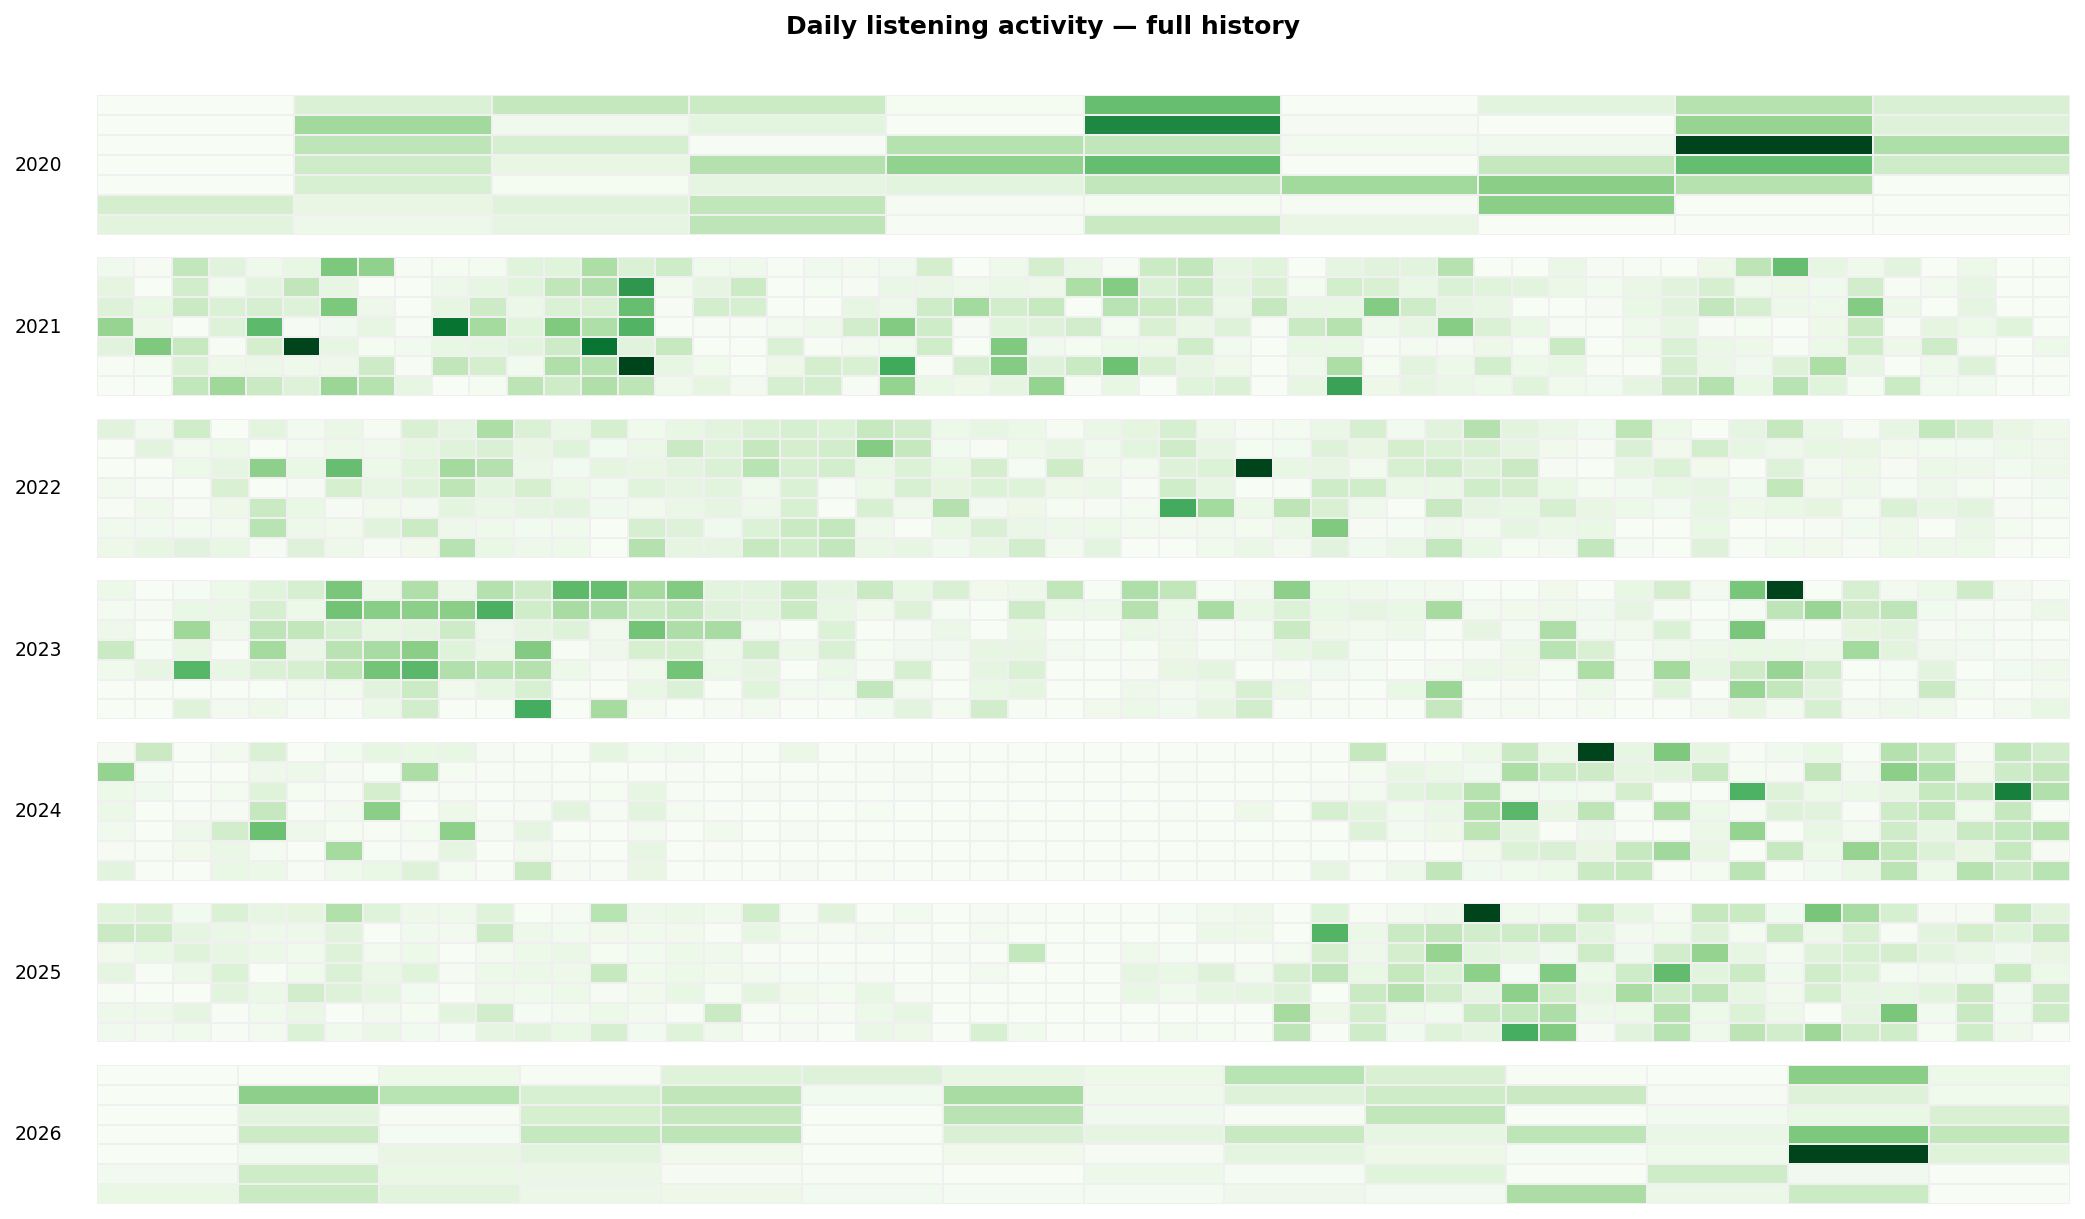

In [4]:
# Calendar heatmap of daily play counts
daily["year"] = daily["date"].dt.year
daily["dow"]  = daily["date"].dt.dayofweek
daily["week"] = daily["date"].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(7, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Daily listening activity — full history", fontweight="bold",
             fontsize=12, y=1.01)

years = sorted(daily["year"].unique())
for ax, yr in zip(axes, years):
    yr_data = daily[daily["year"] == yr].copy()
    # Pivot: rows = day of week, columns = week number
    pivot = yr_data.pivot_table(index="dow", columns="week",
                                values="plays", aggfunc="sum", fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap="Greens", cbar=False,
                linewidths=0.2, linecolor="#f0f0f0",
                xticklabels=False, yticklabels=False)
    ax.set_ylabel(str(yr), fontsize=9, rotation=0, labelpad=28, va="center")
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../outputs/02_calendar_heatmap.png", bbox_inches="tight")
plt.show()


---
## 3. Artist engagement — beyond play counts

Play count alone doesn't capture how engaged the listening actually was. Completion rate (finishing a track vs skipping or stopping) tells a more nuanced story about which artists hold attention.


In [5]:
artist_stats = df_tracks.groupby("artist_name").agg(
    plays            = ("track_name", "count"),
    hours            = ("minutes", lambda x: x.sum() / 60),
    completion_rate  = ("completed", "mean"),
    skip_rate        = ("skipped", "mean"),
    unique_tracks    = ("track_name", "nunique"),
).round(3)
artist_stats = (artist_stats[artist_stats["plays"] >= 50]
                .sort_values("plays", ascending=False))

print(f"Artists with 50+ plays: {len(artist_stats)}")
print()
print(artist_stats.head(15).to_string())


Artists with 50+ plays: 225

                     plays    hours  completion_rate  skip_rate  unique_tracks
artist_name                                                                   
NCT DREAM            12022  503.866            0.640      0.182            151
NCT 127               3034  107.938            0.490      0.269            115
EXO                   2796   98.832            0.502      0.163            201
TOMORROW X TOGETHER   2364   89.238            0.581      0.116             92
BAEKHYUN              2072   80.024            0.542      0.192             57
Iravu                 2008   72.391            0.719      0.234             46
ENHYPEN               1952   66.357            0.589      0.144             88
SEVENTEEN             1818   59.153            0.494      0.179            121
LE SSERAFIM           1436   43.342            0.464      0.390             78
aespa                 1416   40.633            0.390      0.350             99
Red Velvet            1

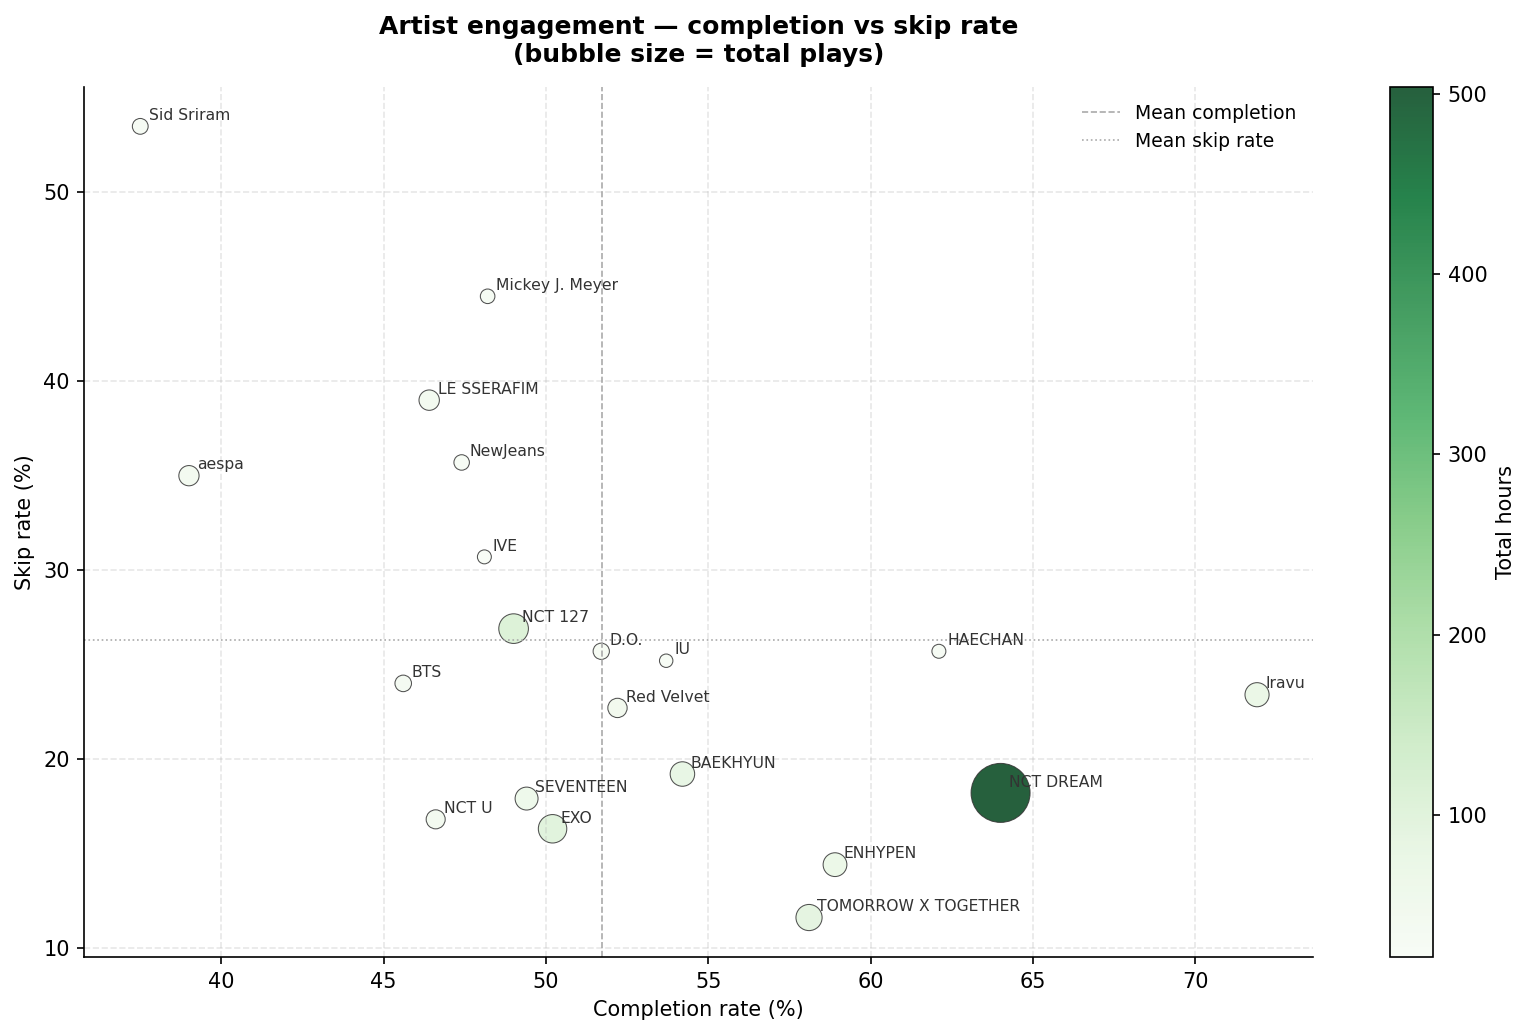

In [12]:
top20 = artist_stats.head(20).copy()
top20["completion_pct"] = top20["completion_rate"] * 100
top20["skip_pct"]       = top20["skip_rate"] * 100

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    top20["completion_pct"],
    top20["skip_pct"],
    s=top20["plays"] / 15,
    c=top20["hours"],
    cmap="Greens",
    alpha=0.85,
    edgecolors="#333",
    linewidths=0.5,
)

for _, row in top20.iterrows():
    ax.annotate(
        row.name,
        xy=(row["completion_pct"], row["skip_pct"]),
        xytext=(4, 3), textcoords="offset points",
        fontsize=7.5, color="#333",
    )

plt.colorbar(scatter, ax=ax, label="Total hours")
ax.set_xlabel("Completion rate (%)")
ax.set_ylabel("Skip rate (%)")
ax.set_title("Artist engagement — completion vs skip rate\n(bubble size = total plays)",
             fontweight="bold", pad=12)
ax.axvline(x=top20["completion_pct"].mean(), color="#aaa",
           linestyle="--", linewidth=0.8, label="Mean completion")
ax.axhline(y=top20["skip_pct"].mean(), color="#aaa",
           linestyle=":", linewidth=0.8, label="Mean skip rate")
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/02_artist_engagement.png", bbox_inches="tight")
plt.show()

---
## 4. How often do tracks get replayed?

44.4% of tracks in the dataset were played exactly once. At the other end, 131 tracks were played more than 100 times and 2 tracks crossed 500 plays. The replay distribution is heavily right-skewed.


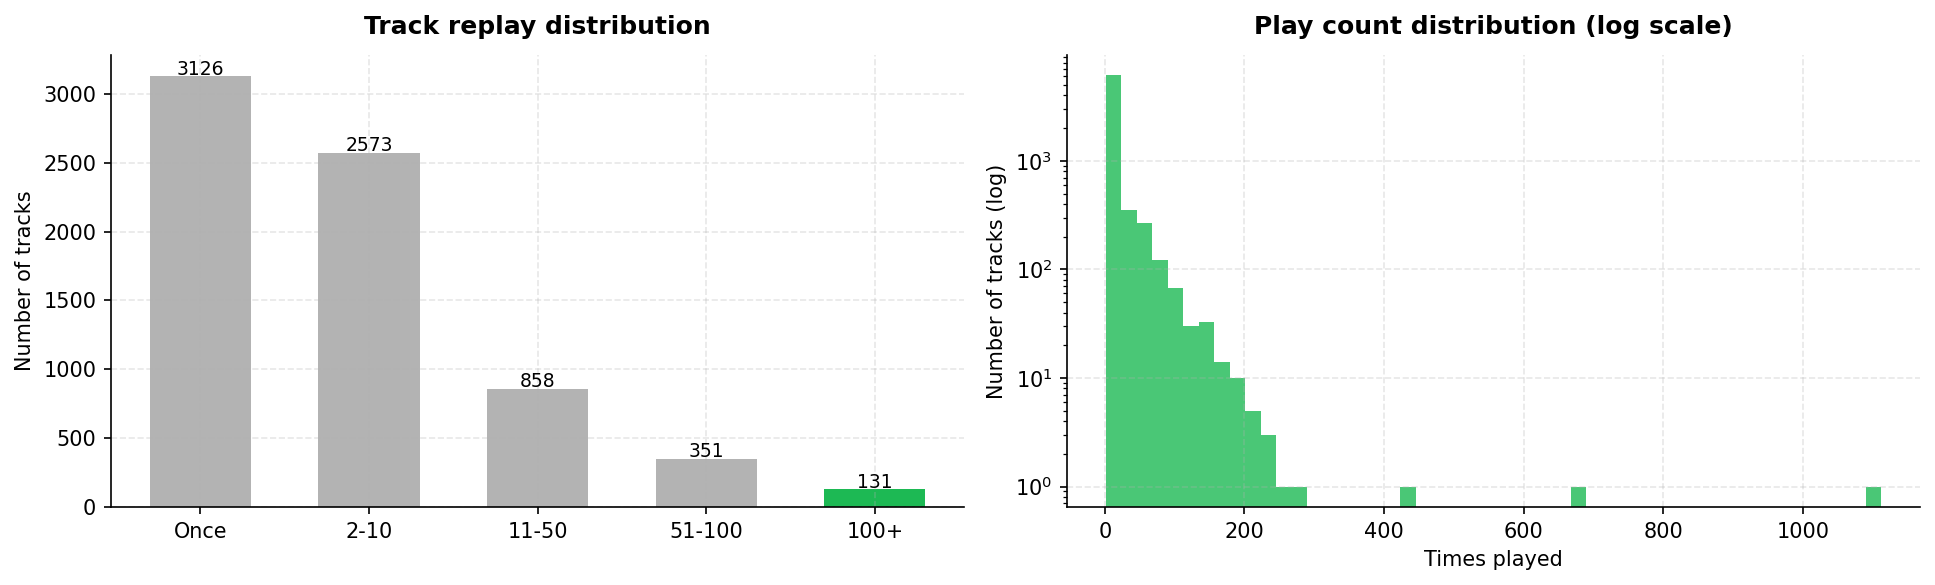

Top 10 most replayed tracks:
track_name
Teddy Bear                1112
Seethakaalam (Reprise)     672
Like We Just Met           445
Hello Future               272
Candy                      257
Moon                       235
Parichayamila              231
Rainbow                    230
Never Goodbye              216
In My Dreams               216


In [13]:
track_plays = df_tracks["track_name"].value_counts()

buckets = {
    "Once":      (track_plays == 1).sum(),
    "2-10":      ((track_plays >= 2)   & (track_plays <= 10)).sum(),
    "11-50":     ((track_plays >= 11)  & (track_plays <= 50)).sum(),
    "51-100":    ((track_plays >= 51)  & (track_plays <= 100)).sum(),
    "100+":      (track_plays > 100).sum(),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart of replay buckets
colors = [PALETTE["muted"]] * 4 + [PALETTE["primary"]]
axes[0].bar(buckets.keys(), buckets.values(), color=colors,
            edgecolor="none", width=0.6)
axes[0].set_title("Track replay distribution", fontweight="bold", pad=10)
axes[0].set_ylabel("Number of tracks")
for i, (k, v) in enumerate(buckets.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=9)

# Log-scale histogram of raw play counts
axes[1].hist(track_plays.values, bins=50, color=PALETTE["primary"],
             alpha=0.8, edgecolor="none", log=True)
axes[1].set_title("Play count distribution (log scale)", fontweight="bold", pad=10)
axes[1].set_xlabel("Times played")
axes[1].set_ylabel("Number of tracks (log)")

plt.tight_layout()
plt.savefig("../outputs/02_replay_distribution.png", bbox_inches="tight")
plt.show()

print("Top 10 most replayed tracks:")
print(track_plays.head(10).to_string())


---
## 5. Shuffle vs intentional listening

40.6% of plays happened with shuffle on. The behavioural difference between the two modes is measurable.


             plays  skip_pct  completion_pct  avg_minutes
Intentional  47855      21.8            51.3        2.128
Shuffle      32657      44.4            44.5        1.896


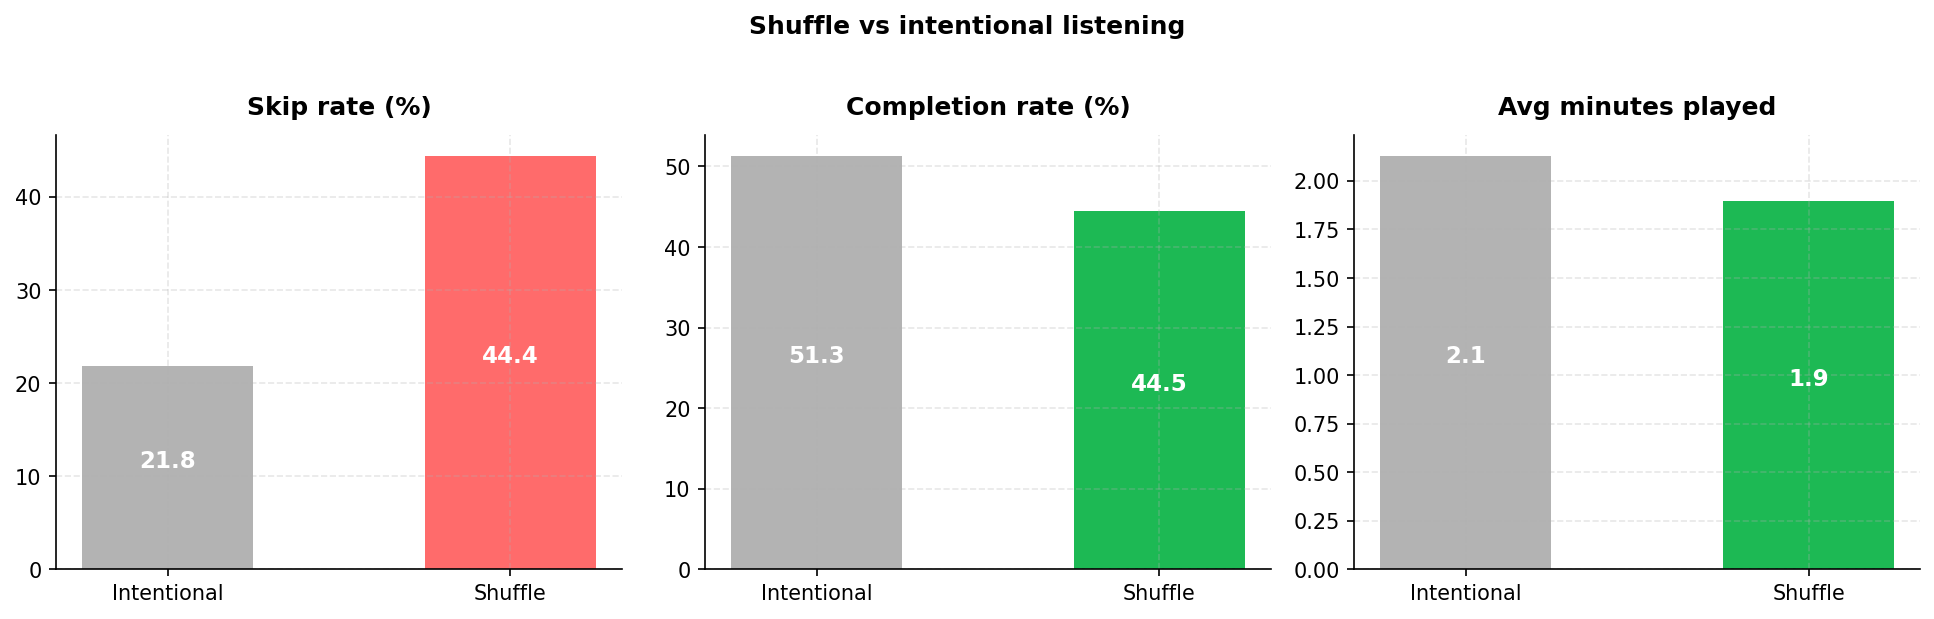

In [14]:
shuffle_stats = df_tracks.groupby("shuffle").agg(
    plays          = ("track_name", "count"),
    skip_rate      = ("skipped", "mean"),
    completion     = ("completed", "mean"),
    avg_minutes    = ("minutes", "mean"),
).round(3)
shuffle_stats.index = ["Intentional", "Shuffle"]
shuffle_stats["skip_pct"]       = (shuffle_stats["skip_rate"] * 100).round(1)
shuffle_stats["completion_pct"] = (shuffle_stats["completion"] * 100).round(1)
print(shuffle_stats[["plays","skip_pct","completion_pct","avg_minutes"]].to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = [
    ("skip_pct",       "Skip rate (%)",       [PALETTE["muted"], PALETTE["accent"]]),
    ("completion_pct", "Completion rate (%)", [PALETTE["muted"], PALETTE["primary"]]),
    ("avg_minutes",    "Avg minutes played",  [PALETTE["muted"], PALETTE["primary"]]),
]
for ax, (col, label, colors) in zip(axes, metrics):
    ax.bar(["Intentional","Shuffle"], shuffle_stats[col].values,
           color=colors, edgecolor="none", width=0.5)
    ax.set_title(label, fontweight="bold", pad=10)
    for i, v in enumerate(shuffle_stats[col].values):
        ax.text(i, v * 0.5, f"{v:.1f}", ha="center", color="white",
                fontweight="bold", fontsize=11)

plt.suptitle("Shuffle vs intentional listening", fontweight="bold",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/02_shuffle_vs_intentional.png", bbox_inches="tight")
plt.show()


---
## 6. Platform differences

Most listening happened on Android, but the platform shapes the behaviour. Windows sessions have the lowest skip rate and the highest completion rate, which makes sense — desktop listening tends to be more deliberate.


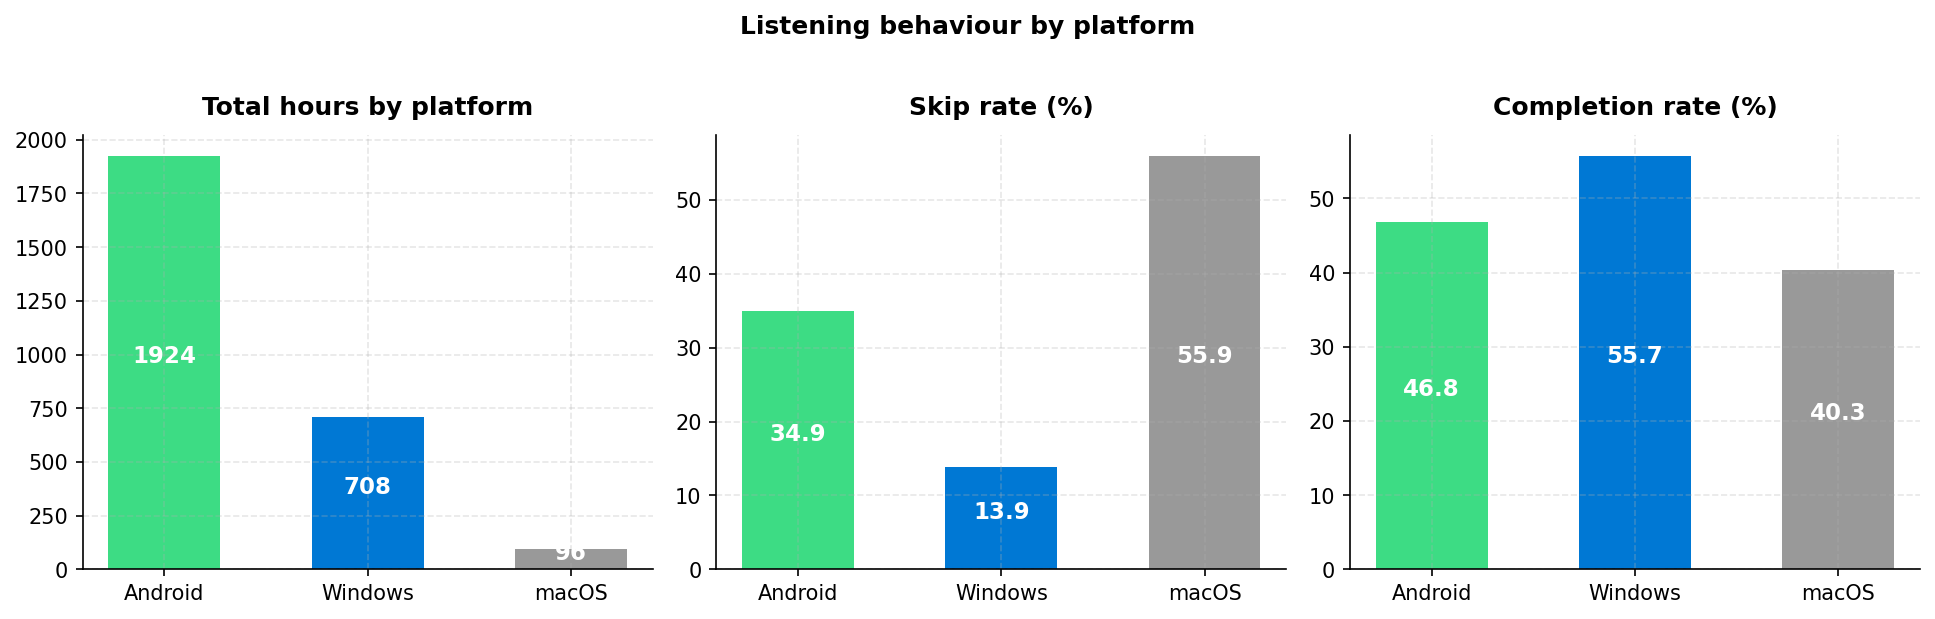

In [15]:
plat_stats = df_tracks[df_tracks["platform_clean"] != "Other"].groupby("platform_clean").agg(
    plays          = ("track_name", "count"),
    hours          = ("minutes", lambda x: x.sum() / 60),
    skip_rate      = ("skipped", "mean"),
    completion     = ("completed", "mean"),
).round(3)
plat_stats["skip_pct"]       = (plat_stats["skip_rate"] * 100).round(1)
plat_stats["completion_pct"] = (plat_stats["completion"] * 100).round(1)

platform_colors = {"Android": PALETTE["android"],
                   "Windows": PALETTE["windows"],
                   "macOS":   PALETTE["macos"]}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (col, title) in zip(axes, [
    ("hours",          "Total hours by platform"),
    ("skip_pct",       "Skip rate (%)"),
    ("completion_pct", "Completion rate (%)"),
]):
    colors = [platform_colors.get(p, PALETTE["muted"]) for p in plat_stats.index]
    ax.bar(plat_stats.index, plat_stats[col], color=colors,
           edgecolor="none", width=0.55)
    ax.set_title(title, fontweight="bold", pad=10)
    for i, v in enumerate(plat_stats[col]):
        ax.text(i, v * 0.5, f"{v:.0f}" if col == "hours" else f"{v:.1f}",
                ha="center", color="white", fontweight="bold", fontsize=11)

plt.suptitle("Listening behaviour by platform", fontweight="bold",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/02_platform.png", bbox_inches="tight")
plt.show()


---
## 7. Does time of day affect engagement?

Morning has the highest volume but also the highest skip rate. Late-night listening has the lowest skip rate of any period and the highest completion rate — more intentional, fewer distractions.


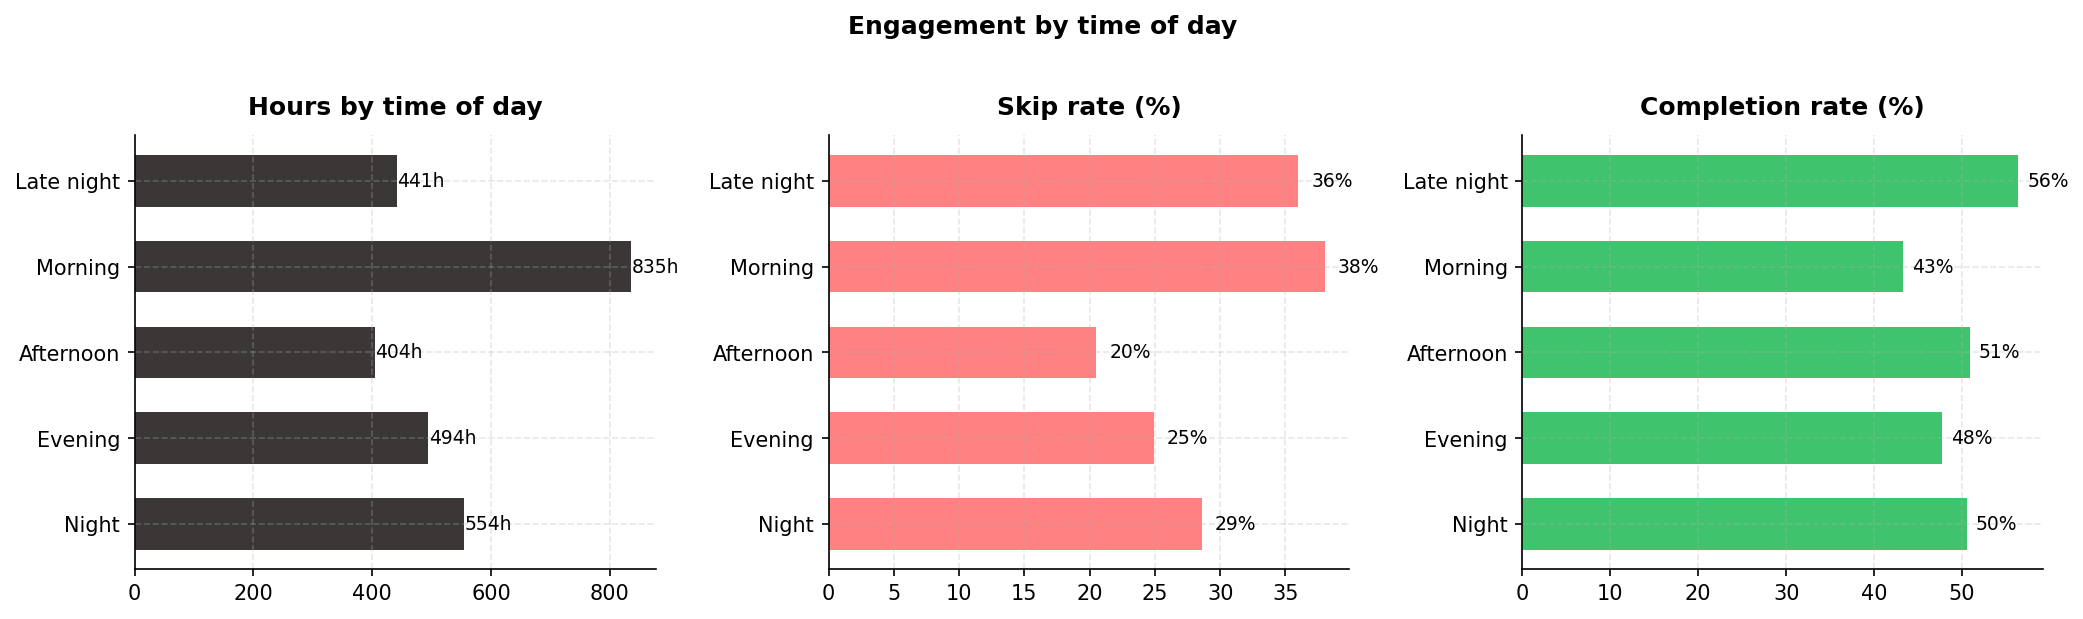

                   plays  hours  skip_pct  completion_pct
time_bucket                                              
Late night (0-5)   11814  440.9      36.0            56.4
Morning (6-11)     26629  835.4      38.0            43.3
Afternoon (12-16)  11571  404.5      20.5            50.9
Evening (17-20)    14550  494.0      24.9            47.7
Night (21-23)      15948  553.9      28.6            50.5


In [16]:
def time_bucket(h):
    if h <= 5:  return "Late night (0-5)"
    if h <= 11: return "Morning (6-11)"
    if h <= 16: return "Afternoon (12-16)"
    if h <= 20: return "Evening (17-20)"
    return "Night (21-23)"

df_tracks["time_bucket"] = df_tracks["hour"].apply(time_bucket)
order = ["Late night (0-5)","Morning (6-11)","Afternoon (12-16)",
         "Evening (17-20)","Night (21-23)"]

tb = df_tracks.groupby("time_bucket").agg(
    plays=("track_name","count"),
    hours=("minutes", lambda x: x.sum()/60),
    skip_pct=("skipped", lambda x: x.mean()*100),
    completion_pct=("completed", lambda x: x.mean()*100),
).reindex(order).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
short_labels = ["Late night","Morning","Afternoon","Evening","Night"]

for ax, (col, title, color) in zip(axes, [
    ("hours",          "Hours by time of day",     PALETTE["dark"]),
    ("skip_pct",       "Skip rate (%)",             PALETTE["accent"]),
    ("completion_pct", "Completion rate (%)",       PALETTE["primary"]),
]):
    ax.barh(short_labels[::-1], tb[col].values[::-1],
            color=color, alpha=0.85, edgecolor="none", height=0.6)
    ax.set_title(title, fontweight="bold", pad=10)
    for i, v in enumerate(tb[col].values[::-1]):
        ax.text(v + 1, i, f"{v:.0f}" + ("%" if "pct" in col else "h"),
                va="center", fontsize=9)

plt.suptitle("Engagement by time of day", fontweight="bold",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/02_time_of_day_engagement.png", bbox_inches="tight")
plt.show()

print(tb[["plays","hours","skip_pct","completion_pct"]].to_string())


---
## 8. Most-played albums

Albums reveal something play counts at the track level can obscure — which bodies of work got listened to as a whole, not just cherry-picked.


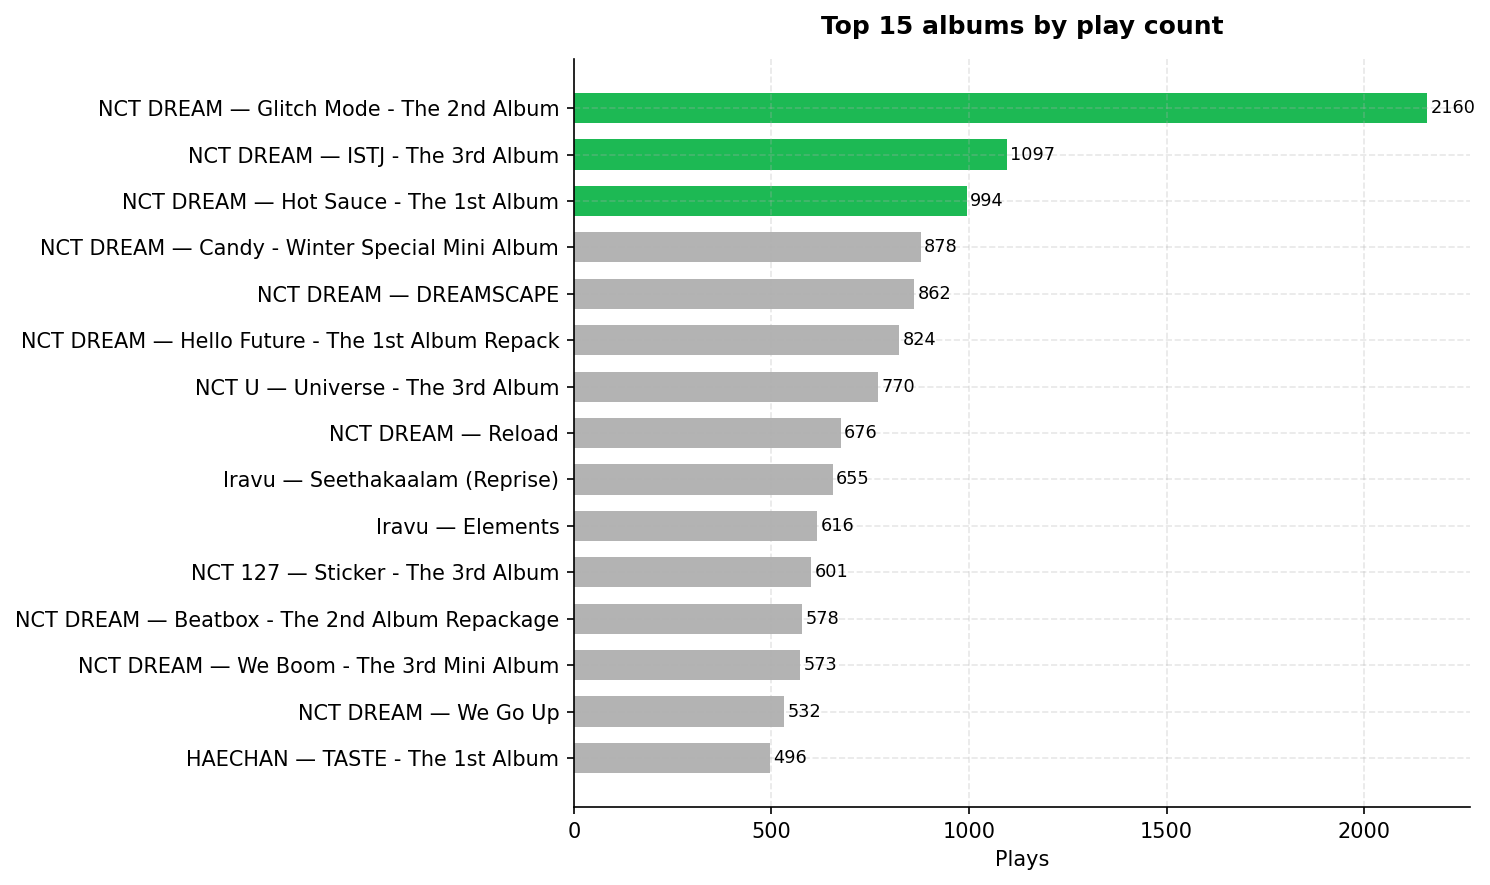

In [17]:
album_stats = df_tracks.groupby("album_name").agg(
    plays  = ("track_name", "count"),
    hours  = ("minutes", lambda x: x.sum()/60),
    artist = ("artist_name", lambda x: x.mode()[0]),
).sort_values("plays", ascending=False).head(15).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{row['artist']} — {idx[:35]}" for idx, row in album_stats.iterrows()]
colors = [PALETTE["primary"] if i < 3 else PALETTE["muted"]
          for i in range(len(album_stats))]

ax.barh(labels[::-1], album_stats["plays"].values[::-1],
        color=colors[::-1], edgecolor="none", height=0.65)
ax.set_title("Top 15 albums by play count", fontweight="bold", pad=12)
ax.set_xlabel("Plays")
for i, v in enumerate(album_stats["plays"].values[::-1]):
    ax.text(v + 8, i, str(v), va="center", fontsize=8.5)

plt.tight_layout()
plt.savefig("../outputs/02_top_albums.png", bbox_inches="tight")
plt.show()


---
## What this analysis adds

A few things stand out that the EDA didn't surface:

The session data confirms that most listening happens in short bursts (median 13 minutes, 6 tracks) — but the long tail of 815 sessions over an hour means the dataset contains both passive background listening and deep focused sessions. That distinction matters for modelling.

The shuffle vs intentional gap is significant enough to use as a feature: skip rate nearly doubles when shuffle is on (44% vs 22%), and completion drops by 7 points. A skip model trained without this flag would be noisier than it needs to be.

The 144-day streak in mid-to-late 2025 is an outlier worth flagging before time-series modelling — sustained engagement at that level will pull trend estimates.

Next: **Notebook 03** builds the ML models using the features identified here.
